# CrossCell Performance Benchmark

This notebook runs a complete performance benchmark comparing CrossCell against other single-cell data conversion tools:

| Tool | Language | RDS→H5AD | H5AD→RDS |
|------|----------|----------|----------|
| **CrossCell** | Rust CLI | ✅ | ✅ |
| **Zellkonverter** | R | ✅ | ✅ |
| **anndataR** | R | ✅ | ✅ |
| **convert2anndata** | R | ✅ | ❌ |
| **easySCF** | R + Python | ✅ | ❌ |

**Datasets:** 55 test cases from SeuratData, scanpy, scvelo, squidpy, and CELLxGENE (1.4k–73k cells).

**Metrics:** Conversion time (seconds), peak memory (MB), output file size (MB).

---

## Prerequisites & Environment Setup

This benchmark runs inside a pre-built Docker image that contains all required tools.
You only need **Docker** installed on your machine.

### Option A: Pull from Docker Hub (Recommended)

```bash
docker pull crosscell/benchmark:latest
```

Then start the Jupyter notebook server:

```bash
mkdir -p data/generated benchmark/results benchmark/notebooks

docker run -it --rm \
  -p 8888:8888 \
  -v $(pwd)/data:/benchmark/data \
  -v $(pwd)/benchmark/results:/benchmark/results \
  -v $(pwd)/benchmark/notebooks:/benchmark/notebooks \
  crosscell/benchmark:latest \
  jupyter notebook --ip=0.0.0.0 --port=8888 --no-browser --allow-root \
    --NotebookApp.token='' --NotebookApp.password=''
```

Open http://localhost:8888 and navigate to this notebook.



### Option B: Build from Source

```bash
git clone https://github.com/crosscell/crosscell.git
cd crosscell
cargo build --release
cp target/release/crosscell benchmark/
docker-compose -f benchmark/docker-compose.benchmark.yml build notebook
docker-compose -f benchmark/docker-compose.benchmark.yml up notebook
```

### What's Inside the Docker Image

| Component | Version | Purpose |
|-----------|---------|--------|
| R | 4.5.x | R runtime |
| Python | 3.12 | Python runtime (venv at `/opt/venv`) |
| Seurat | 5.x | Seurat V5 (also reads V4 objects) |
| zellkonverter | 1.20+ | Bioconductor conversion tool |
| anndataR | 1.0+ | Bioconductor AnnData interface |
| convert2anndata | 0.2+ | settylab conversion tool |
| easySCFr / easySCFpy | latest | easySCF R + Python packages |
| anndata (Python) | 0.12.3 | AnnData Python library |
| CrossCell | 0.1.x | Rust CLI binary |
| Jupyter + IRkernel | latest | Notebook server with R kernel |
| matplotlib | latest | Plotting |

### Container Directory Layout

```
/benchmark/
├── data/generated/    # Dataset files (.rds, .h5ad)
├── config/            # benchmark_testcases.json, datasets.json
├── results/           # Benchmark output JSON files
├── scripts/           # Benchmark runner scripts (read-only)
├── notebooks/         # This notebook
└── test_data/         # Unit test data (read-only)
```

### System Requirements

- **RAM:** 8 GB minimum, 16 GB recommended
- **Disk:** ~5 GB for Docker image + ~4 GB for datasets
- **Time:** Full benchmark ~30–60 min

---
## Step 0: Environment Check

In [1]:
import subprocess, sys, os, json, time, re, glob, shutil
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'

def run(cmd, timeout=300):
    r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    return r.returncode, r.stdout, r.stderr

def run_r(script, timeout=300):
    wrapped = f'suppressWarnings(suppressMessages({{\n{script.strip()}\n}}))'
    return run(['Rscript', '-e', wrapped], timeout=timeout)

print(f'Python: {sys.version.split()[0]}')
rc, out, _ = run(['crosscell', '--version'])
print(f'CrossCell: {out.strip()}' if rc == 0 else '❌ CrossCell not found')
rc, out, _ = run_r('cat(R.version.string)')
print(f'{out.strip()}' if rc == 0 else '❌ R not found')
for pkg in ['zellkonverter', 'anndataR', 'convert2anndata', 'easySCFr', 'Seurat']:
    rc, out, _ = run_r(f"cat(as.character(packageVersion('{pkg}')))")
    print(f'  {pkg}: {out.strip()}' if rc == 0 else f'  ❌ {pkg}: not installed')
import anndata; print(f'  anndata (Python): {anndata.__version__}')
print('\n✅ Environment ready')

Python: 3.12.12
CrossCell: crosscell 0.1.0
R version 4.5.2 (2025-10-31)
  zellkonverter: 1.20.1
  anndataR: 1.0.1
  convert2anndata: 0.2.0
  easySCFr: 0.2.2.7
  Seurat: 5.4.0
  anndata (Python): 0.12.3

✅ Environment ready


---
## Step 1: Download Datasets from Zenodo

All benchmark datasets (RDS + H5AD) are archived on Zenodo.
This cell downloads and extracts them. Existing files are skipped.

> **TODO:** Replace `ZENODO_RECORD_ID` below with the actual Zenodo deposit ID once uploaded.

In [2]:
DATA_DIR = '/benchmark/data/generated'
os.makedirs(DATA_DIR, exist_ok=True)

# ── Zenodo configuration ──
ZENODO_RECORD_ID = '00000000'  # TODO: fill in real record ID
ZENODO_BASE = f'https://zenodo.org/records/{ZENODO_RECORD_ID}/files'

# Split archives — download only what you need
ARCHIVES = [
    'seurat_v4_datasets.tar.gz',
    'seurat_v5_datasets.tar.gz',
    'h5ad_small_datasets.tar.gz',
    'h5ad_spatial_datasets.tar.gz',
    'h5ad_cellxgene_datasets.tar.gz',
]

# Check if data already exists
rds_files = glob.glob(os.path.join(DATA_DIR, '*.rds'))
h5ad_files = glob.glob(os.path.join(DATA_DIR, '*.h5ad'))
print(f'Existing data: {len(rds_files)} .rds, {len(h5ad_files)} .h5ad')

if len(rds_files) >= 40 and len(h5ad_files) >= 10:
    print('\u2705 Datasets already present, skipping download.')
else:
    for archive in ARCHIVES:
        url = f'{ZENODO_BASE}/{archive}'
        local = f'/tmp/{archive}'
        print(f'\n\U0001f4e5 Downloading {archive}...')
        rc, out, err = run(
            ['curl', '-L', '-C', '-', '--retry', '5', '--retry-delay', '3',
             '-o', local, url],
            timeout=3600
        )
        if rc == 0 and os.path.exists(local):
            size_mb = os.path.getsize(local) / 1024 / 1024
            print(f'  \u2705 Downloaded: {size_mb:.0f} MB')
            print(f'  \U0001f4e6 Extracting...')
            rc2, _, err2 = run(['tar', 'xzf', local, '-C', '/benchmark'], timeout=600)
            if rc2 == 0:
                os.remove(local)
                print(f'  \u2705 Extracted')
            else:
                print(f'  \u274c Extraction failed: {err2[:300]}')
        else:
            print(f'  \u274c Download failed (rc={rc}): {err[:300]}')

    rds_files = glob.glob(os.path.join(DATA_DIR, '*.rds'))
    h5ad_files = glob.glob(os.path.join(DATA_DIR, '*.h5ad'))
    print(f'\n\u2705 Total: {len(rds_files)} .rds, {len(h5ad_files)} .h5ad')


Existing data: 44 .rds, 13 .h5ad
✅ Datasets already present, skipping download.


### Verify downloaded data

In [3]:
rds_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.rds')))
h5ad_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.h5ad')))

print(f'RDS files:  {len(rds_files):3d}  (expected >= 42)')
print(f'H5AD files: {len(h5ad_files):3d}  (expected >= 13)')

# Spot-check key files
key_files = [
    'seurat_v4_pbmc3k_raw.rds', 'seurat_v5_pbmc3k_raw.rds',
    'seurat_v4_hcabm40k_raw.rds', 'seurat_v5_ssHippo_raw.rds',
    'scanpy_pbmc3k.h5ad', 'cellxgene_brain_40k.h5ad',
    'scvelo_pancreas.h5ad', 'squidpy_merfish.h5ad',
]
print(f'\nSpot check ({len(key_files)} key files):')
all_ok = True
for name in key_files:
    path = os.path.join(DATA_DIR, name)
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024 / 1024
        print(f'  \u2705 {name:45s} {size:8.1f} MB')
    else:
        print(f'  \u274c {name:45s} MISSING')
        all_ok = False

if all_ok:
    print('\n\u2705 All key files present.')
else:
    print('\n\u26a0\ufe0f Some files missing. Check download or Zenodo archive.')


RDS files:   44  (expected >= 42)
H5AD files:  13  (expected >= 13)

Spot check (8 key files):
  ✅ seurat_v4_pbmc3k_raw.rds                           9.8 MB
  ✅ seurat_v5_pbmc3k_raw.rds                           4.9 MB
  ✅ seurat_v4_hcabm40k_raw.rds                       180.2 MB
  ✅ seurat_v5_ssHippo_raw.rds                         47.8 MB
  ✅ scanpy_pbmc3k.h5ad                                 5.6 MB
  ✅ cellxgene_brain_40k.h5ad                         464.1 MB
  ✅ scvelo_pancreas.h5ad                              50.0 MB
  ✅ squidpy_merfish.h5ad                              49.2 MB

✅ All key files present.


---
## Step 2: Inspect Dataset Summary

List all input datasets with their file sizes. These are the source files used for conversion, not the output sizes.

In [4]:
import pandas as pd
rows = []
for f in sorted(glob.glob(os.path.join(DATA_DIR, '*'))):
    name = os.path.basename(f)
    ext = os.path.splitext(name)[1]
    if ext not in ('.rds', '.h5ad'): continue
    size_mb = os.path.getsize(f) / 1024 / 1024
    rows.append({'file': name, 'format': ext, 'input_size_mb': round(size_mb, 1)})
df_data = pd.DataFrame(rows)
print(f'Total: {len(df_data)} files  |  .rds: {len(df_data[df_data.format==".rds"])}  |  .h5ad: {len(df_data[df_data.format==".h5ad"])}  |  {df_data.input_size_mb.sum():.0f} MB')
df_data

Total: 57 files  |  .rds: 44  |  .h5ad: 13  |  7226 MB


,file,format,input_size_mb
0,cellxgene_brain_40k.h5ad,.h5ad,464.1
1,cellxgene_heart_23k.h5ad,.h5ad,164.3
2,cellxgene_pbmc_15k.h5ad,.h5ad,71.0
3,scanpy_pbmc3k.h5ad,.h5ad,5.6
4,scanpy_pbmc3k_processed.h5ad,.h5ad,23.5
5,scvelo_dentategyrus.h5ad,.h5ad,23.7
6,scvelo_pancreas.h5ad,.h5ad,50.0
7,seurat_v4_bmcite_processed.rds,.rds,244.6
8,seurat_v4_bmcite_processed.roundtrip.rds,.rds,141.4
9,seurat_v4_bmcite_raw.rds,.rds,167.1


---
## Step 3: Load Test Matrix & Define Benchmark Engine

In [5]:
MATRIX_FILE = '/benchmark/config/benchmark_testcases.json'
RESULTS_DIR = '/benchmark/results'
OUTPUT_TMP_DIR = '/tmp/benchmark_output'
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_TMP_DIR, exist_ok=True)

with open(MATRIX_FILE) as f:
    matrix = json.load(f)

s = matrix['summary']
print(f'Test matrix v{matrix["version"]}')
print(f'Tools: {", ".join(t["name"] for t in matrix["tools"])}')
print(f'Test cases: {s["total_test_cases"]} (RDS→H5AD: {s["rds_to_h5ad_count"]}, H5AD→RDS: {s["h5ad_to_rds_count"]})')
print(f'Scale: {s["scale_distribution"]}')

Test matrix v2.0
Tools: crosscell, zellkonverter, anndataR, convert2anndata, easySCF
Test cases: 55 (RDS→H5AD: 42, H5AD→RDS: 13)
Scale: {'rds_to_h5ad': {'small': 6, 'medium': 16, 'large': 20}, 'h5ad_to_rds': {'small': 7, 'medium': 2, 'large': 4}}


---
## Step 4: Define Benchmark Engine

Tool command generators, measurement functions, and the benchmark runner — all inlined from `run_benchmark.py`.

In [6]:
# ── Path helpers ──
def get_output_path(test_id, tool, direction):
    ext = 'h5ad' if direction == 'rds_to_h5ad' else 'rds'
    return os.path.join(OUTPUT_TMP_DIR, f'{tool}_{test_id}.{ext}')

def resolve_input_path(raw_path):
    if raw_path.startswith('data/'):
        return os.path.join('/benchmark', raw_path)
    return raw_path

# ── Tool command generators ──
def cmd_crosscell(inp, out, direction):
    fmt = 'anndata' if direction == 'rds_to_h5ad' else 'seurat'
    return ['crosscell', 'convert', '-i', inp, '-o', out, '-f', fmt]

def cmd_zellkonverter(inp, out, direction):
    if direction == 'rds_to_h5ad':
        s = f'''
library(Seurat); library(zellkonverter); library(SingleCellExperiment)
obj <- readRDS("{inp}"); obj <- UpdateSeuratObject(obj)
sce <- as.SingleCellExperiment(obj); writeH5AD(sce, "{out}")
'''
    else:
        s = f'''
library(zellkonverter); library(Seurat); library(SingleCellExperiment)
fix_dn <- function(sce) {{
  if (is.null(rownames(sce))||length(rownames(sce))==0) {{
    if ("_index" %in% names(rowData(sce))) rownames(sce)<-rowData(sce)[["_index"]]
    else if ("gene_ids" %in% names(rowData(sce))) rownames(sce)<-rowData(sce)[["gene_ids"]]
    else rownames(sce)<-paste0("Gene_",seq_len(nrow(sce)))
  }}
  if (is.null(colnames(sce))||length(colnames(sce))==0) {{
    if ("_index" %in% names(colData(sce))) colnames(sce)<-colData(sce)[["_index"]]
    else colnames(sce)<-paste0("Cell_",seq_len(ncol(sce)))
  }}
  sce
}}
ok<-FALSE
tryCatch({{ sce<-readH5AD("{inp}",reader="R"); sce<-fix_dn(sce)
  obj<-as.Seurat(sce,counts="X",data=NULL); saveRDS(obj,"{out}"); ok<-TRUE
}}, error=function(e) cat("R reader failed:",conditionMessage(e),"\\n"))
if (!ok) {{
  Sys.setenv(RETICULATE_PYTHON="/opt/venv/bin/python3")
  library(reticulate); use_python("/opt/venv/bin/python3",required=TRUE)
  ad<-import("anndata"); adata<-ad$read_h5ad("{inp}")
  sce<-AnnData2SCE(adata); sce<-fix_dn(sce)
  obj<-as.Seurat(sce,counts="X",data=NULL); saveRDS(obj,"{out}")
}}
'''
    return ['Rscript', '-e', s.strip()]

def cmd_anndatar(inp, out, direction):
    if direction == 'rds_to_h5ad':
        s = f'library(anndataR);library(Seurat);obj<-readRDS("{inp}");obj<-UpdateSeuratObject(obj);if(file.exists("{out}"))file.remove("{out}");ad<-as_AnnData(obj);write_h5ad(ad,"{out}")'
    else:
        s = f'library(anndataR);library(Seurat);ad<-read_h5ad("{inp}");obj<-ad$as_Seurat();saveRDS(obj,"{out}")'
    return ['Rscript', '-e', s]

def cmd_convert2anndata(inp, out, direction):
    if direction != 'rds_to_h5ad': return None
    s = f'library(convert2anndata);library(Seurat);obj<-readRDS("{inp}");obj<-UpdateSeuratObject(obj);sce<-convert_seurat_to_sce(obj);ad<-convert_to_anndata(sce);anndata::write_h5ad(ad,"{out}")'
    return ['Rscript', '-e', s]

def cmd_easyscf(inp, out, direction):
    if direction != 'rds_to_h5ad': return None
    s = f'library(easySCFr);library(Seurat);obj<-readRDS("{inp}");obj<-UpdateSeuratObject(obj);saveH5(obj,"{out}")'
    return ['Rscript', '-e', s]

TOOL_COMMANDS = {
    'crosscell': cmd_crosscell,
    'zellkonverter': cmd_zellkonverter,
    'anndataR': cmd_anndatar,
    'convert2anndata': cmd_convert2anndata,
    'easySCF': cmd_easyscf,
}

print('✅ Benchmark engine loaded:', list(TOOL_COMMANDS.keys()))

✅ Benchmark engine loaded: ['crosscell', 'zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']


In [7]:
# ── Measurement ──
def split_time_stderr(stderr):
    marker = '\tCommand being timed:'
    idx = stderr.find(marker)
    if idx >= 0: return stderr[:idx].rstrip(), stderr[idx:]
    return stderr, ''

def run_with_measurement(cmd, timeout=600):
    time_cmd = ['/usr/bin/time', '-v'] + cmd
    start = time.time()
    try:
        result = subprocess.run(time_cmd, capture_output=True, text=True, timeout=timeout)
        elapsed = time.time() - start
    except subprocess.TimeoutExpired:
        return False, timeout, 0, 'TIMEOUT'
    tool_stderr, time_stats = split_time_stderr(result.stderr)
    peak_mem_mb = 0
    m = re.search(r'Maximum resident set size \(kbytes\): (\d+)', time_stats)
    if m: peak_mem_mb = int(m.group(1)) / 1024.0
    error_output = tool_stderr
    if result.returncode != 0 and result.stdout:
        error_output = result.stdout.rstrip() + '\n' + tool_stderr
    return result.returncode == 0, elapsed, peak_mem_mb, error_output

def get_file_size_mb(path):
    try: return os.path.getsize(path) / (1024*1024)
    except OSError: return 0

# ── Single test runner ──
def run_single_test(tool_name, case, direction, runs=3, timeout=600):
    test_id = case['id']
    inp = resolve_input_path(case['input'])
    out = get_output_path(test_id, tool_name, direction)
    if not os.path.exists(inp):
        return {'test_id': test_id, 'status': 'skipped', 'reason': f'input not found: {inp}'}
    cmd_fn = TOOL_COMMANDS.get(tool_name)
    if not cmd_fn:
        return {'test_id': test_id, 'status': 'error', 'reason': f'unknown tool: {tool_name}'}
    cmd = cmd_fn(inp, out, direction)
    if cmd is None:
        return {'test_id': test_id, 'status': 'skipped', 'reason': f'{tool_name} does not support {direction}'}
    times, mems = [], []
    for i in range(runs):
        if os.path.exists(out): os.remove(out)
        ok, elapsed, peak, stderr = run_with_measurement(cmd, timeout)
        if not ok:
            return {'test_id': test_id, 'dataset': case.get('dataset',''), 'direction': direction,
                    'status': 'failed', 'error': stderr[:3000], 'run': i+1}
        times.append(elapsed); mems.append(peak)
    times.sort(); mems.sort()
    return {
        'test_id': test_id, 'dataset': case.get('dataset',''), 'direction': direction,
        'status': 'success',
        'conversion_time_seconds': round(times[len(times)//2], 3),
        'peak_memory_mb': round(mems[len(mems)//2], 1),
        'output_file_size_mb': round(get_file_size_mb(out), 2),
        'all_times': [round(t,3) for t in times],
        'all_mems': [round(m,1) for m in mems],
        'n_cells': case.get('n_cells'), 'n_genes': case.get('n_genes'),
        'scale': case.get('scale'), 'seurat_version': case.get('seurat_version',''),
        'type': case.get('type',''),
    }

print('✅ Measurement functions loaded')

✅ Measurement functions loaded


In [8]:
def run_tool_benchmark(tool_name, runs=3, timeout=600):
    """Run benchmark for a single tool across all test cases. Returns results dict."""
    results = {
        'tool': tool_name,
        'timestamp': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
        'config': {'runs_per_test': runs, 'timeout_seconds': timeout},
        'rds_to_h5ad': [], 'h5ad_to_rds': [], 'summary': {},
    }
    tool_directions = []
    for t in matrix['tools']:
        if t['name'] == tool_name:
            tool_directions = t.get('directions', [])
    total = success = failed = skipped = 0
    for d in ['rds_to_h5ad', 'h5ad_to_rds']:
        if d not in tool_directions:
            print(f'  ⏭️  {tool_name} does not support {d}')
            continue
        cases = matrix['test_cases'].get(d, [])
        print(f'\n  {d} ({len(cases)} test cases)')
        print(f'  {"─"*95}')
        print(f'  {"#":>5}  {"test_id":40s} {"cells":>6} × {"genes":<6}       {"time":>6}  {"peak_mem":>8}  {"out_size":>8}')
        print(f'  {"─"*95}')
        for i, case in enumerate(cases):
            total += 1
            tid = case['id']
            nc = case.get('n_cells','?'); ng = case.get('n_genes','?')
            print(f'  [{i+1:2d}/{len(cases)}] {tid:40s} {nc:>6} × {ng:<6}', end=' ')
            r = run_single_test(tool_name, case, d, runs, timeout)
            if r['status'] == 'success':
                success += 1
                print(f'✅ {r["conversion_time_seconds"]:6.2f}s  {r["peak_memory_mb"]:7.0f} MB  {r["output_file_size_mb"]:7.1f} MB')
            elif r['status'] == 'skipped':
                skipped += 1
                print(f'⏭️  {r.get("reason","")[:60]}')
            else:
                failed += 1
                print(f'❌ {r.get("error","")[:80]}')
            results[d].append(r)
    results['summary'] = {'total': total, 'success': success, 'failed': failed, 'skipped': skipped}
    # Save to JSON
    out_file = os.path.join(RESULTS_DIR, f'{tool_name}.json')
    with open(out_file, 'w') as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f'\n  📊 {tool_name}: {success}/{total} success, {failed} failed, {skipped} skipped')
    print(f'  💾 Saved: {out_file}')
    return results

# Store all results
all_results = {}
TOOLS = list(TOOL_COMMANDS.keys())
print('✅ Runner ready. Tools:', TOOLS)

✅ Runner ready. Tools: ['crosscell', 'zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']


---
## Step 5: Benchmark — CrossCell

Rust CLI, supports both RDS→H5AD and H5AD→RDS.

In [9]:
t0 = time.time()
all_results['crosscell'] = run_tool_benchmark('crosscell', runs=3, timeout=600)
print(f'\n⏱️ Total: {time.time()-t0:.0f}s')


  rds_to_h5ad (42 test cases)
  ───────────────────────────────────────────────────────────────────────────────────────────────
      #  test_id                                   cells × genes          time  peak_mem  out_size
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [ 1/42] v4_pbmc3k_raw                              2700 × 13714  ✅   0.46s      152 MB     26.2 MB
  [ 2/42] v4_pbmc3k_processed                        2700 × 13714  ✅   0.68s      232 MB     27.3 MB
  [ 3/42] v5_pbmc3k_raw                              2700 × 13714  ✅   0.32s      114 MB     26.2 MB
  [ 4/42] v5_pbmc3k_processed                        2700 × 13714  ✅   0.79s      246 MB     27.3 MB
  [ 5/42] v4_stxKidney_raw                           1438 × 31053  ✅   1.73s      566 MB     91.9 MB
  [ 6/42] v5_stxKidney_raw                           1438 × 31053  ✅   1.15s      409 MB     91.9 MB
  [ 7/42] v4_celegans_raw                            6188 × 20222  ✅

---
## Step 6: Benchmark — Zellkonverter

R/Bioconductor, uses basilisk for Python interop. Supports both directions.

In [10]:
t0 = time.time()
all_results['zellkonverter'] = run_tool_benchmark('zellkonverter', runs=3, timeout=600)
print(f'\n⏱️ Total: {time.time()-t0:.0f}s')


  rds_to_h5ad (42 test cases)
  ───────────────────────────────────────────────────────────────────────────────────────────────
      #  test_id                                   cells × genes          time  peak_mem  out_size
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [ 1/42] v4_pbmc3k_raw                              2700 × 13714  ✅  12.74s     1071 MB     53.1 MB
  [ 2/42] v4_pbmc3k_processed                        2700 × 13714  ✅  14.88s     1207 MB     54.5 MB
  [ 3/42] v5_pbmc3k_raw                              2700 × 13714  ✅  11.81s      964 MB     26.9 MB
  [ 4/42] v5_pbmc3k_processed                        2700 × 13714  ✅  14.53s     1169 MB     54.5 MB
  [ 5/42] v4_stxKidney_raw                           1438 × 31053  ❌ Loading required package: SeuratObject
Loading required package: sp

Attaching p
  [ 6/42] v5_stxKidney_raw                           1438 × 31053  ✅  13.09s     1323 MB     93.3 MB
  [ 7/42] v4_celega

---
## Step 7: Benchmark — anndataR

R/Bioconductor native AnnData interface. Supports both directions.

In [11]:
t0 = time.time()
all_results['anndataR'] = run_tool_benchmark('anndataR', runs=3, timeout=600)
print(f'\n⏱️ Total: {time.time()-t0:.0f}s')


  rds_to_h5ad (42 test cases)
  ───────────────────────────────────────────────────────────────────────────────────────────────
      #  test_id                                   cells × genes          time  peak_mem  out_size
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [ 1/42] v4_pbmc3k_raw                              2700 × 13714  ✅   5.72s      647 MB     53.5 MB
  [ 2/42] v4_pbmc3k_processed                        2700 × 13714  ✅   7.03s      712 MB     58.0 MB
  [ 3/42] v5_pbmc3k_raw                              2700 × 13714  ✅   5.27s      586 MB     27.3 MB
  [ 4/42] v5_pbmc3k_processed                        2700 × 13714  ✅   7.05s      706 MB     58.8 MB
  [ 5/42] v4_stxKidney_raw                           1438 × 31053  ❌ Loading required package: SeuratObject
Loading required package: sp

Attaching p
  [ 6/42] v5_stxKidney_raw                           1438 × 31053  ✅   6.85s      939 MB     94.0 MB
  [ 7/42] v4_celega

---
## Step 8: Benchmark — convert2anndata

R package from settylab. Only supports RDS→H5AD.

In [12]:
t0 = time.time()
all_results['convert2anndata'] = run_tool_benchmark('convert2anndata', runs=3, timeout=600)
print(f'\n⏱️ Total: {time.time()-t0:.0f}s')


  rds_to_h5ad (42 test cases)
  ───────────────────────────────────────────────────────────────────────────────────────────────
      #  test_id                                   cells × genes          time  peak_mem  out_size
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [ 1/42] v4_pbmc3k_raw                              2700 × 13714  ❌ [2026-02-11 15:29:59] Input object class: Seurat 
[2026-02-11 15:29:59] Converti
  [ 2/42] v4_pbmc3k_processed                        2700 × 13714  ❌ [2026-02-11 15:30:12] Input object class: Seurat 
[2026-02-11 15:30:12] Converti
  [ 3/42] v5_pbmc3k_raw                              2700 × 13714  ❌ [2026-02-11 15:30:25] Input object class: Seurat 
[2026-02-11 15:30:25] Converti
  [ 4/42] v5_pbmc3k_processed                        2700 × 13714  ❌ [2026-02-11 15:30:42] Input object class: Seurat 
[2026-02-11 15:30:42] Converti
  [ 5/42] v4_stxKidney_raw                           1438 × 31053  ❌ Loadi

---
## Step 9: Benchmark — easySCF

R + Python package. Only supports RDS→H5AD (custom H5 format, not standard H5AD).

In [13]:
t0 = time.time()
all_results['easySCF'] = run_tool_benchmark('easySCF', runs=3, timeout=600)
print(f'\n⏱️ Total: {time.time()-t0:.0f}s')


  rds_to_h5ad (42 test cases)
  ───────────────────────────────────────────────────────────────────────────────────────────────
      #  test_id                                   cells × genes          time  peak_mem  out_size
  ───────────────────────────────────────────────────────────────────────────────────────────────
  [ 1/42] v4_pbmc3k_raw                              2700 × 13714  ✅   8.32s      670 MB      6.3 MB
  [ 2/42] v4_pbmc3k_processed                        2700 × 13714  ✅  11.81s      892 MB     16.2 MB
  [ 3/42] v5_pbmc3k_raw                              2700 × 13714  ✅   7.55s      618 MB      6.3 MB
  [ 4/42] v5_pbmc3k_processed                        2700 × 13714  ✅  10.32s      816 MB     16.2 MB
  [ 5/42] v4_stxKidney_raw                           1438 × 31053  ❌ Loading required package: SeuratObject
Loading required package: sp

Attaching p
  [ 6/42] v5_stxKidney_raw                           1438 × 31053  ✅   6.56s      697 MB      0.0 MB
  [ 7/42] v4_celega

---
## Step 10: Build Comparison Table

In [14]:
# Reload from disk in case some tools were run in previous sessions
for tool in TOOLS:
    p = os.path.join(RESULTS_DIR, f'{tool}.json')
    if os.path.exists(p) and tool not in all_results:
        with open(p) as f: all_results[tool] = json.load(f)

for tool, data in all_results.items():
    s = data['summary']
    print(f'{tool:20s} {s["success"]:3d}/{s["total"]:3d} success  {s["failed"]:2d} failed  {s["skipped"]:2d} skipped')

rows = []
for tool, data in all_results.items():
    for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
        for r in data.get(direction, []):
            rows.append({
                'tool': tool, 'test_id': r['test_id'], 'direction': direction,
                'status': r['status'],
                'time_s': r.get('conversion_time_seconds'),
                'mem_mb': r.get('peak_memory_mb'),
                'size_mb': r.get('output_file_size_mb'),
                'n_cells': r.get('n_cells'), 'n_genes': r.get('n_genes'),
                'scale': r.get('scale',''), 'dataset': r.get('dataset',''),
            })
df = pd.DataFrame(rows)
df_ok = df[df['status']=='success'].copy()
print(f'\nTotal rows: {len(df)}, successful: {len(df_ok)}')
df_ok.head(10)

zellkonverter         54/ 55 success   1 failed   0 skipped
anndataR              44/ 55 success  11 failed   0 skipped
convert2anndata       15/ 42 success  27 failed   0 skipped
easySCF               41/ 42 success   1 failed   0 skipped
crosscell             55/ 55 success   0 failed   0 skipped

Total rows: 249, successful: 209


,tool,test_id,direction,status,time_s,mem_mb,size_mb,n_cells,n_genes,scale,dataset
0,zellkonverter,v4_pbmc3k_raw,rds_to_h5ad,success,12.745,1071.3,53.09,2700.0,13714.0,small,pbmc3k
1,zellkonverter,v4_pbmc3k_processed,rds_to_h5ad,success,14.880,1207.4,54.46,2700.0,13714.0,small,pbmc3k
2,zellkonverter,v5_pbmc3k_raw,rds_to_h5ad,success,11.812,964.0,26.92,2700.0,13714.0,small,pbmc3k
3,zellkonverter,v5_pbmc3k_processed,rds_to_h5ad,success,14.525,1169.1,54.46,2700.0,13714.0,small,pbmc3k
5,zellkonverter,v5_stxKidney_raw,rds_to_h5ad,success,13.086,1323.4,93.34,1438.0,31053.0,small,stxKidney
6,zellkonverter,v4_celegans_raw,rds_to_h5ad,success,13.327,1273.5,116.56,6188.0,20222.0,medium,celegans.embryo
7,zellkonverter,v4_celegans_processed,rds_to_h5ad,success,14.613,1387.6,119.76,6188.0,20222.0,medium,celegans.embryo
8,zellkonverter,v5_celegans_raw,rds_to_h5ad,success,11.596,1082.8,59.44,6188.0,20222.0,medium,celegans.embryo
9,zellkonverter,v5_celegans_processed,rds_to_h5ad,success,15.881,1531.9,119.76,6188.0,20222.0,medium,celegans.embryo
10,zellkonverter,v4_cbmc_raw,rds_to_h5ad,success,14.075,1709.5,190.46,8617.0,20501.0,medium,cbmc


---
## Step 11: Performance Charts

### 11.1 RDS → H5AD: Conversion Time

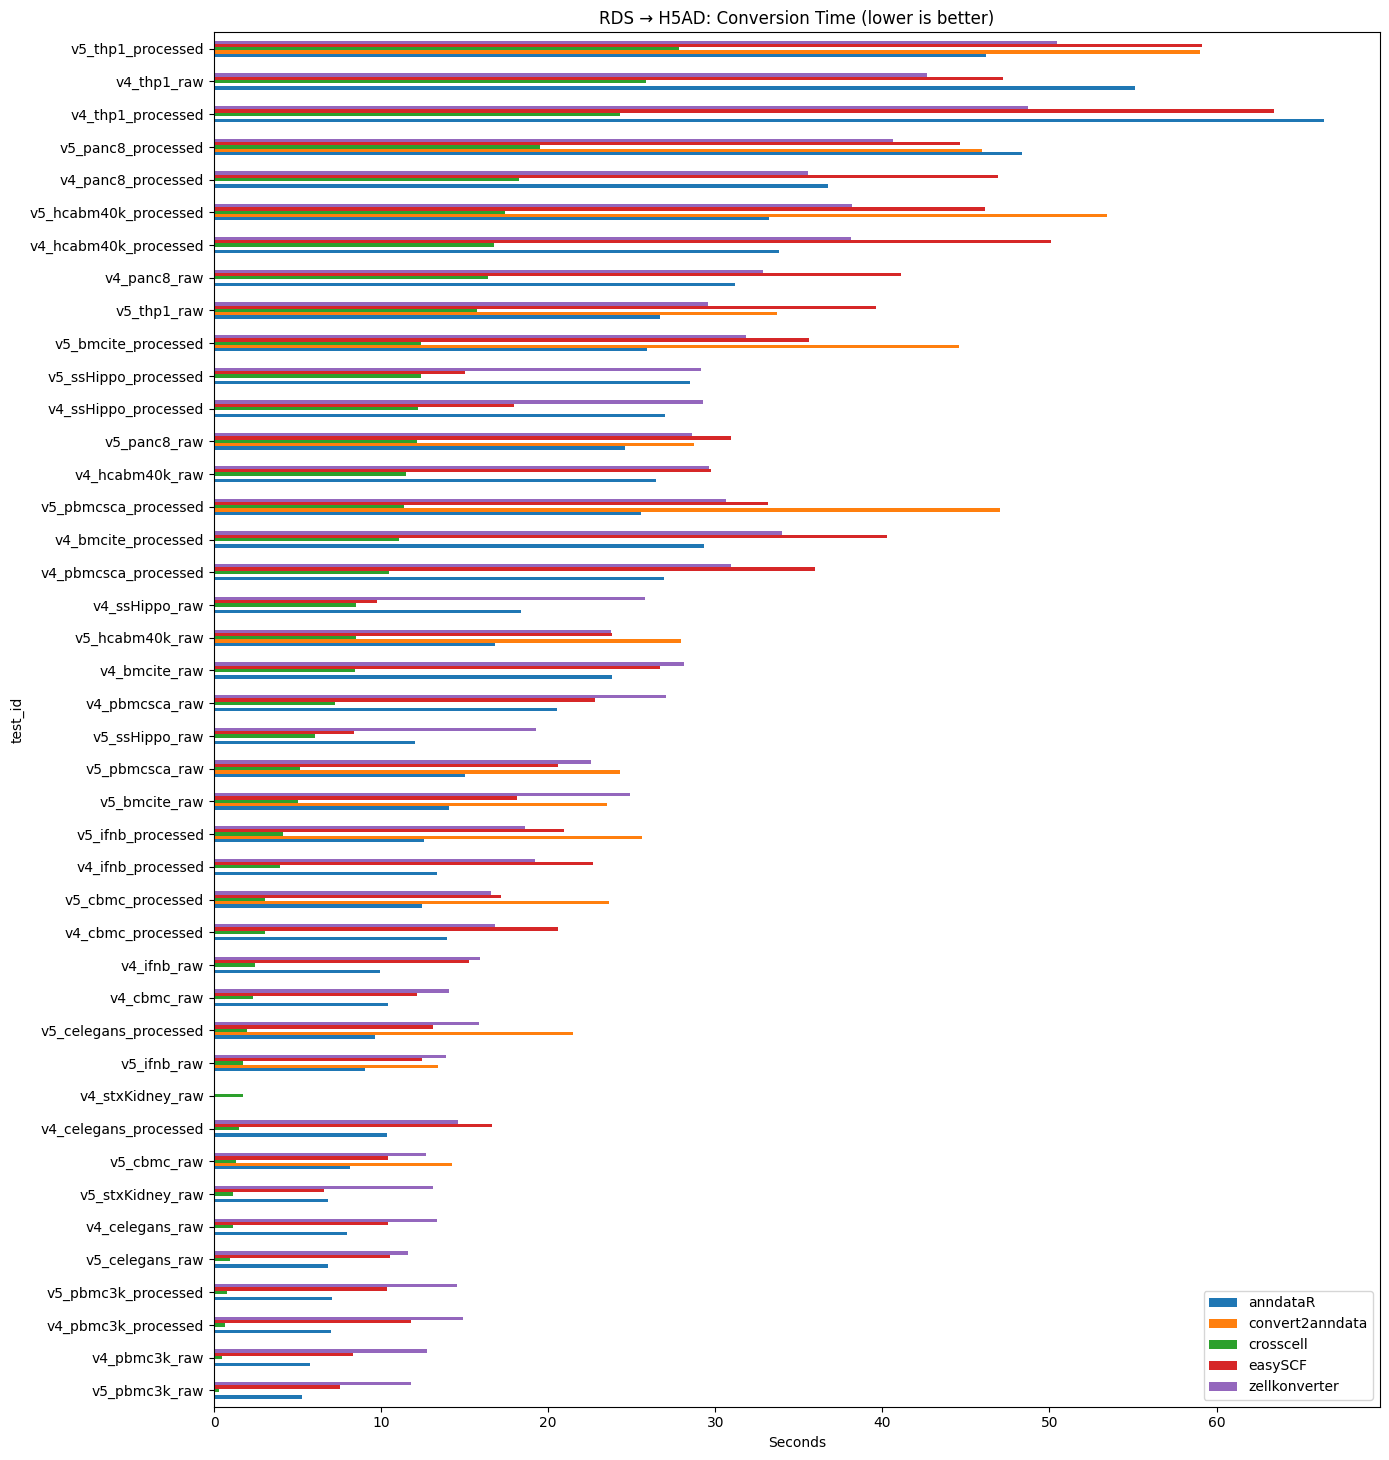

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(direction, metric, ylabel, title):
    sub = df_ok[df_ok['direction']==direction]
    if sub.empty: print(f'No data for {direction}'); return
    pivot = sub.pivot_table(index='test_id', columns='tool', values=metric, aggfunc='first')
    if 'crosscell' in pivot.columns:
        pivot = pivot.sort_values('crosscell', na_position='last')
    fig, ax = plt.subplots(figsize=(14, max(6, len(pivot)*0.35)))
    pivot.plot(kind='barh', ax=ax)
    ax.set_xlabel(ylabel); ax.set_title(title)
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

plot_comparison('rds_to_h5ad', 'time_s', 'Seconds', 'RDS → H5AD: Conversion Time (lower is better)')

### 11.2 RDS → H5AD: Peak Memory

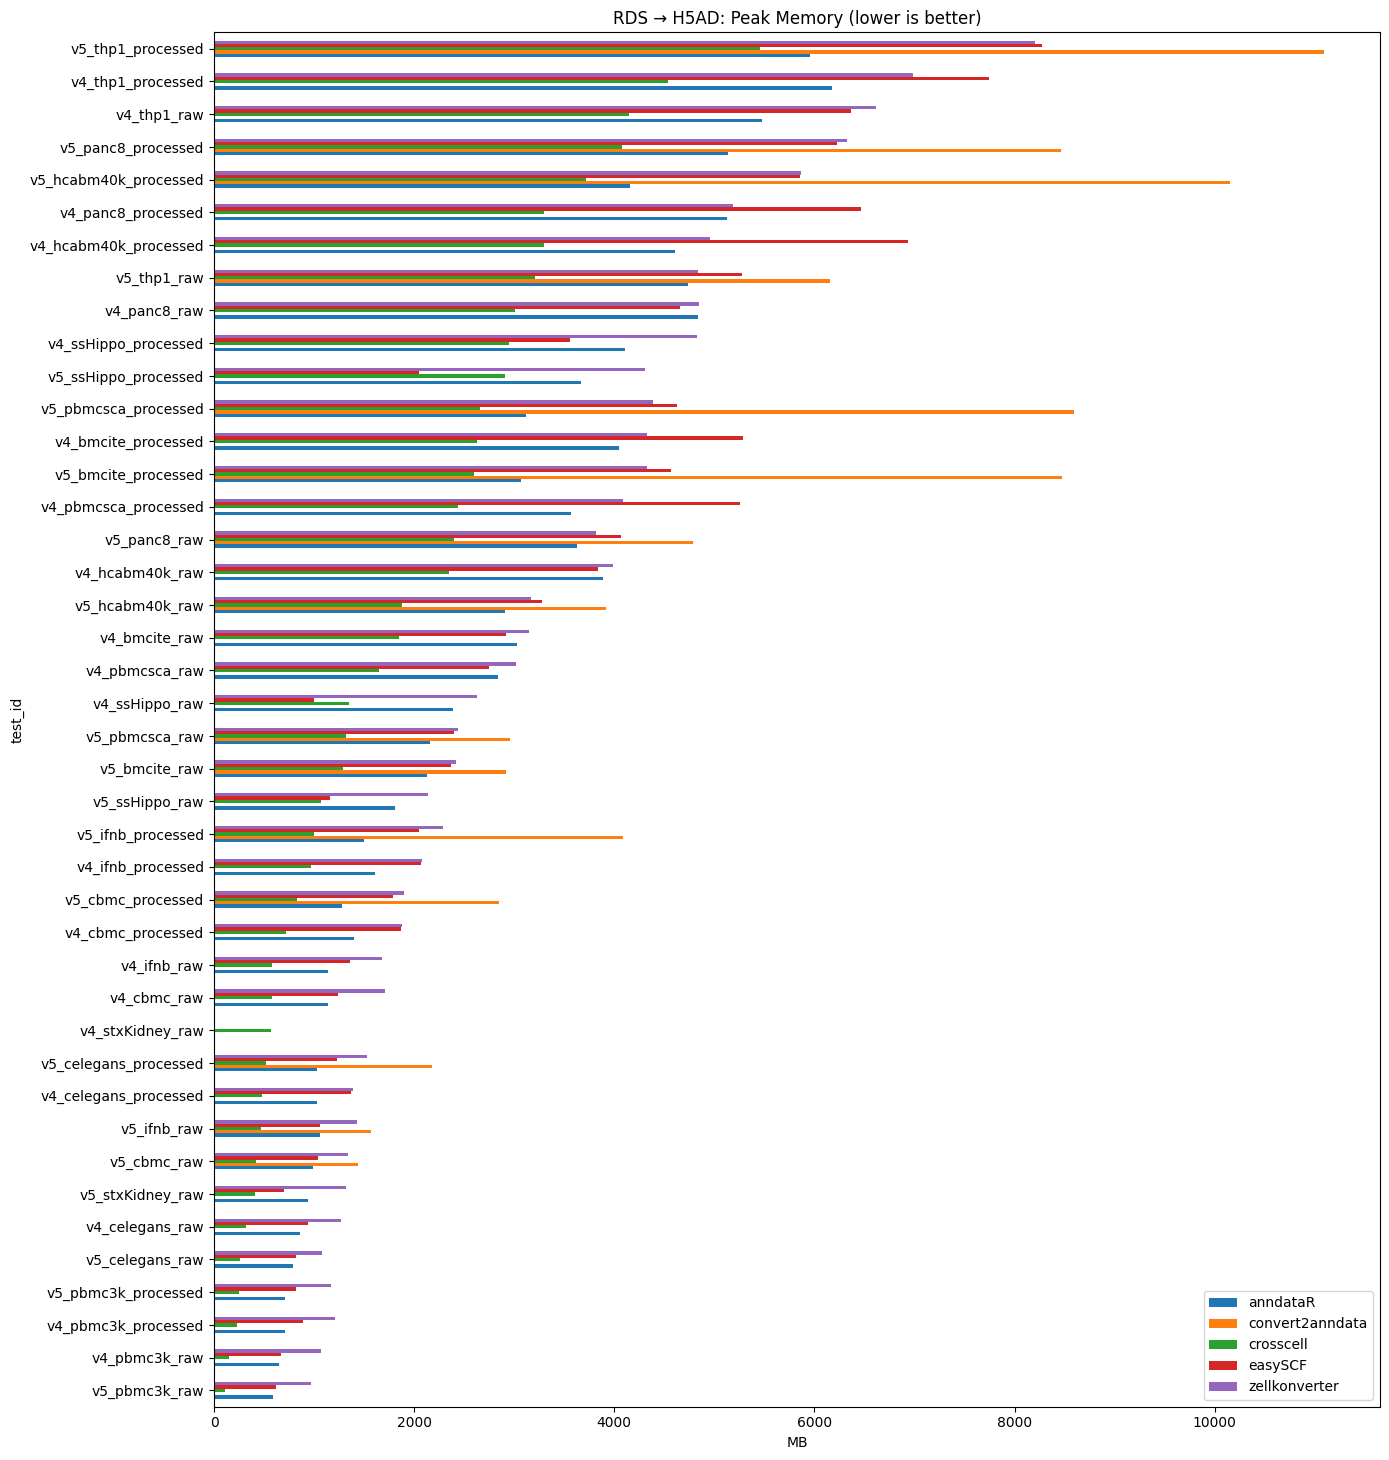

In [16]:
plot_comparison('rds_to_h5ad', 'mem_mb', 'MB', 'RDS → H5AD: Peak Memory (lower is better)')

### 11.3 H5AD → RDS: Conversion Time

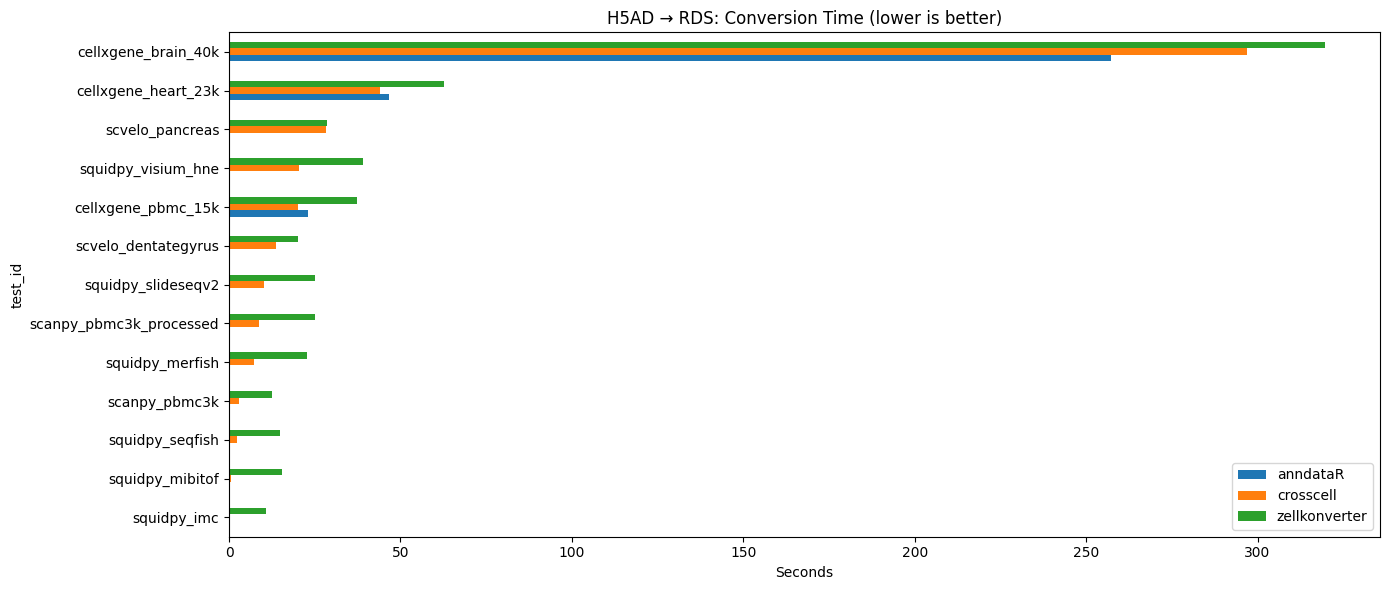

In [17]:
plot_comparison('h5ad_to_rds', 'time_s', 'Seconds', 'H5AD → RDS: Conversion Time (lower is better)')

### 11.4 H5AD → RDS: Peak Memory

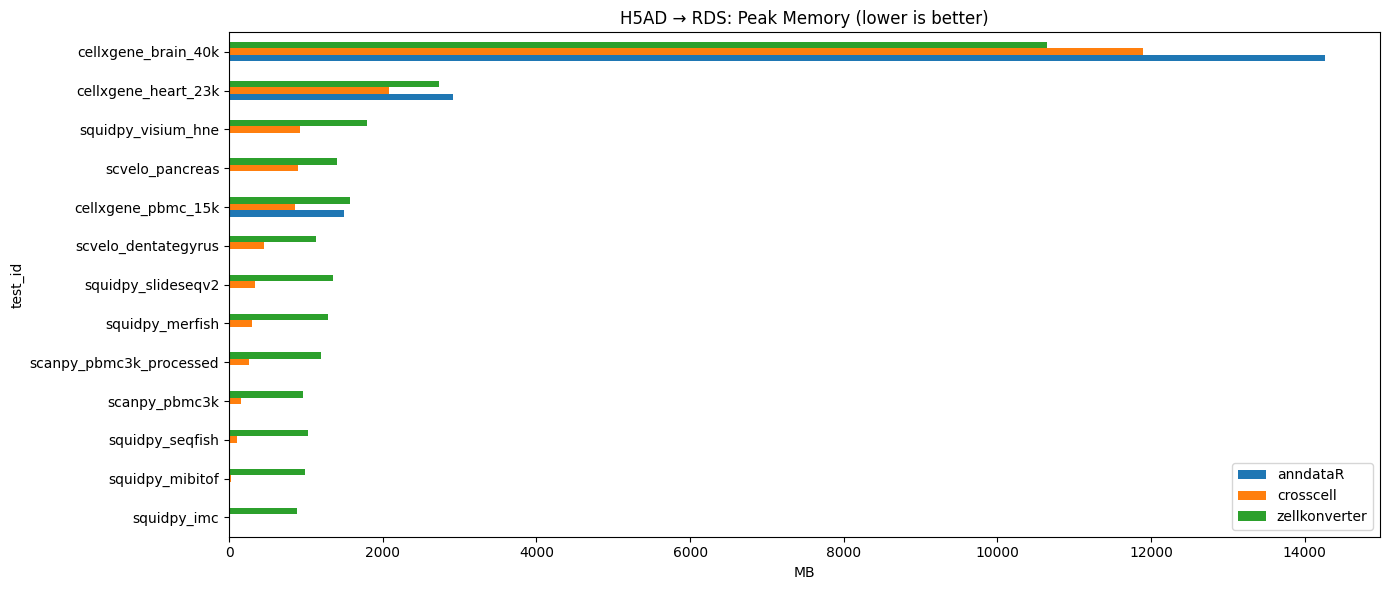

In [18]:
plot_comparison('h5ad_to_rds', 'mem_mb', 'MB', 'H5AD → RDS: Peak Memory (lower is better)')

---
## Step 12: Speedup Analysis

In [19]:
cc = df_ok[df_ok['tool']=='crosscell'].set_index(['test_id','direction'])
for other in ['zellkonverter','anndataR','convert2anndata','easySCF']:
    ot = df_ok[df_ok['tool']==other].set_index(['test_id','direction'])
    m = cc[['time_s','mem_mb']].join(ot[['time_s','mem_mb']], lsuffix='_cc', rsuffix='_other').dropna()
    if m.empty: continue
    m['speedup'] = m['time_s_other']/m['time_s_cc']
    m['mem_ratio'] = m['mem_mb_other']/m['mem_mb_cc']
    print(f'\nCrossCell vs {other} ({len(m)} common tests):')
    print(f'  Time:   {m.speedup.mean():.1f}x avg, {m.speedup.median():.1f}x median (range: {m.speedup.min():.1f}x – {m.speedup.max():.1f}x)')
    print(f'  Memory: {m.mem_ratio.mean():.1f}x avg (CrossCell uses {1/m.mem_ratio.mean():.0%} of {other} memory)')


CrossCell vs zellkonverter (54 common tests):
  Time:   6.7x avg, 3.1x median (range: 1.0x – 37.1x)
  Memory: 4.3x avg (CrossCell uses 23% of zellkonverter memory)

CrossCell vs anndataR (44 common tests):
  Time:   3.9x avg, 2.7x median (range: 0.9x – 16.6x)
  Memory: 1.9x avg (CrossCell uses 54% of anndataR memory)

CrossCell vs convert2anndata (15 common tests):
  Time:   5.1x avg, 4.1x median (range: 2.1x – 11.0x)
  Memory: 2.8x avg (CrossCell uses 35% of convert2anndata memory)

CrossCell vs easySCF (41 common tests):
  Time:   5.6x avg, 3.4x median (range: 1.1x – 23.8x)
  Memory: 2.1x avg (CrossCell uses 47% of easySCF memory)


---
## Step 13: Scaling Analysis

Conversion time vs dataset size (number of cells).

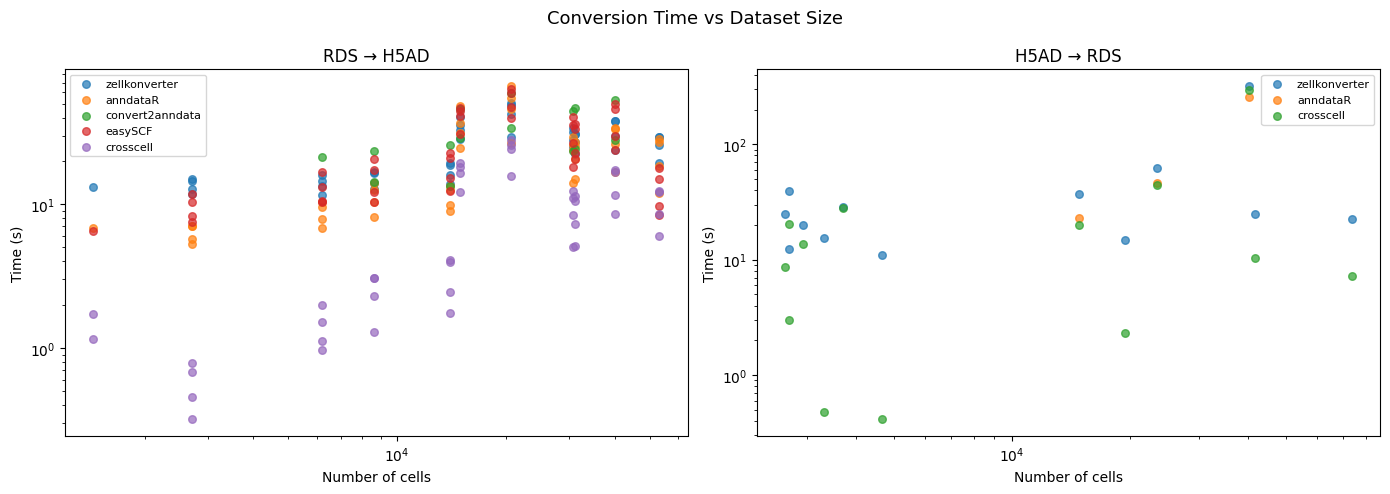

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, d, title in zip(axes, ['rds_to_h5ad','h5ad_to_rds'], ['RDS → H5AD','H5AD → RDS']):
    sub = df_ok[df_ok['direction']==d]
    for tool in sub['tool'].unique():
        t = sub[sub['tool']==tool].sort_values('n_cells')
        ax.scatter(t['n_cells'], t['time_s'], label=tool, alpha=0.7, s=30)
    ax.set_xlabel('Number of cells'); ax.set_ylabel('Time (s)'); ax.set_title(title)
    ax.legend(fontsize=8); ax.set_xscale('log'); ax.set_yscale('log')
plt.suptitle('Conversion Time vs Dataset Size', fontsize=13)
plt.tight_layout(); plt.show()

---
## Step 14: Success Rate Summary

In [ ]:
srows = []
for tool, data in all_results.items():
    for d in ['rds_to_h5ad','h5ad_to_rds']:
        entries = data.get(d,[])
        tot = len(entries)
        ok = sum(1 for e in entries if e['status']=='success')
        fa = sum(1 for e in entries if e['status']=='failed')
        sk = sum(1 for e in entries if e['status']=='skipped')
        srows.append({'tool':tool,'direction':d,'total':tot,'success':ok,'failed':fa,'skipped':sk,
                      'rate': f'{ok/tot*100:.0f}%' if tot>0 else 'N/A'})
pd.DataFrame(srows)

---
## Step 15: Export Results

Save combined results with tool versions for archival / Zenodo.

In [ ]:
versions = {'timestamp': datetime.now().isoformat()}
rc, out, _ = run(['crosscell','--version'])
versions['crosscell'] = out.strip() if rc==0 else 'unknown'
rc, out, _ = run_r('cat(R.version.string)')
versions['R'] = out.strip() if rc==0 else 'unknown'
for pkg in ['Seurat','zellkonverter','anndataR','convert2anndata','easySCFr']:
    rc, out, _ = run_r(f"cat(as.character(packageVersion('{pkg}')))")
    versions[pkg] = out.strip() if rc==0 else 'N/A'
versions['anndata_python'] = anndata.__version__
versions['python'] = sys.version.split()[0]

export = {'versions': versions, 'test_matrix_summary': matrix['summary'], 'results': all_results}
export_path = os.path.join(RESULTS_DIR, 'benchmark_combined.json')
with open(export_path, 'w') as f:
    json.dump(export, f, indent=2, ensure_ascii=False)
print(f'✅ Saved: {export_path} ({os.path.getsize(export_path)/1024:.0f} KB)')
print(json.dumps(versions, indent=2))

---
## Step 16: Files for Zenodo Upload

In [ ]:
print('Files to upload to Zenodo:')
print('='*50)
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json'))):
    size = os.path.getsize(f)/1024
    print(f'  {os.path.basename(f):40s} {size:8.1f} KB')
print(f'\nSuggested metadata:')
print(f'  Title: CrossCell Performance Benchmark Results')
print(f'  Date: {datetime.now().strftime("%Y-%m-%d")}')
print(f'  Keywords: single-cell, format conversion, benchmark, Seurat, AnnData')